# Fixed Brain Tumor MRI Preprocessing Notebook

This notebook fixes the common Kaggle path error by using a robust path resolver:

1. It first tries your previous mounted paths:
   - `/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset`
   - `/kaggle/input/datasets/ishans24/brain-tumor-dataset`
   - `/kaggle/input/datasets/alamshihab075/brain-tumor-mri-dataset-for-deep-learning`
2. If any path is missing, it falls back to `kagglehub.dataset_download()`.
3. It preprocesses every image to RGB, 224 × 224, PNG.
4. It hashes the **preprocessed pixel array** to detect duplicates.
5. It combines **Masoud + Ishans24** into train/validation/internal-test.
6. It keeps **Alamshihab075** only for external validation after removing duplicates with the internal pool.

Final output:

```text
/kaggle/working/final_brain_tumor_preprocessed_dataset
```

Recommended usage in Kaggle:

- Run this notebook first.
- Then use the output folder in your model-training notebook.

## 1. Imports and configuration

In [18]:
import os
import shutil
import hashlib
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

SEED = 42
np.random.seed(SEED)

IMG_SIZE = (224, 224)
CANONICAL_CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

################################
###    CHANGE THIS BASED ON YOUR PATH. The rest should be fine
MAIN_DIRECTORY = "/home/khalid/code/simonwilliams32/MRI_project"
###


WORKING_DIR = os.path.join(MAIN_DIRECTORY, "raw_data")
PREPROCESSED_DIR = os.path.join(WORKING_DIR, "preprocessed_all_brain_tumor_images")
FINAL_DATASET_DIR = os.path.join(WORKING_DIR, "final_brain_tumor_preprocessed_dataset")
REPORT_DIR = os.path.join(WORKING_DIR, "preprocessing_reports")

os.makedirs(WORKING_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

print("Configuration ready.")
print("Image size:", IMG_SIZE)
print("Final dataset directory:", FINAL_DATASET_DIR)

Configuration ready.
Image size: (224, 224)
Final dataset directory: /home/khalid/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset


## 2. Resolve dataset paths safely

In [19]:
import os

RAW_DATA_DIR = os.path.join(MAIN_DIRECTORY, "raw_data")

dataset_paths = {
    "Masoud": os.path.join(RAW_DATA_DIR, "Brain Tumor MRI Dataset"),
    "Ishans24": os.path.join(RAW_DATA_DIR, "Brain Tumor Dataset"),
    "Alamshihab075": os.path.join(RAW_DATA_DIR, "Brain Tumor MRI Dataset for Deep Learning"),
}


## 3. Class-name normalization

In [20]:
class_aliases = {
    "glioma": "glioma",
    "glioma tumor": "glioma",
    "glioma tumour": "glioma",
    "glioma_tumor": "glioma",
    "glioma-tumor": "glioma",
    "meningioma": "meningioma",
    "meningioma tumor": "meningioma",
    "meningioma tumour": "meningioma",
    "meningioma_tumor": "meningioma",
    "meningioma-tumor": "meningioma",
    "pituitary": "pituitary",
    "pituitary tumor": "pituitary",
    "pituitary tumour": "pituitary",
    "pituitary_tumor": "pituitary",
    "pituitary-tumor": "pituitary",
    "notumor": "notumor",
    "no tumor": "notumor",
    "no tumour": "notumor",
    "no_tumor": "notumor",
    "no-tumor": "notumor",
    "normal": "notumor",
    "non tumor": "notumor",
    "non_tumor": "notumor",
    "non-tumor": "notumor",
}


def normalize_text(text):
    text = str(text).lower().strip()
    text = text.replace("_", " ").replace("-", " ")
    text = " ".join(text.split())
    return text


def detect_class_from_path(path):
    for part in Path(path).parts:
        normalized = normalize_text(part)
        if normalized in class_aliases:
            return class_aliases[normalized]
    return None

## 4. Collect image paths

In [21]:
def collect_images(dataset_name, dataset_path):
    rows = []
    skipped_unknown_class = 0

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if not file.lower().endswith(IMAGE_EXTS):
                continue

            image_path = os.path.join(root, file)
            detected_class = detect_class_from_path(image_path)

            if detected_class is None:
                skipped_unknown_class += 1
                continue

            rows.append({
                "Dataset": dataset_name,
                "Original Path": image_path,
                "Class": detected_class,
                "Original Filename": file,
                "Original Relative Path": os.path.relpath(image_path, dataset_path),
                "Original Folder": os.path.relpath(root, dataset_path),
                "Original Extension": Path(file).suffix.lower(),
            })

    return rows, skipped_unknown_class


all_rows = []
skipped_summary = []

for dataset_name, dataset_path in dataset_paths.items():
    rows, skipped = collect_images(dataset_name, dataset_path)
    print(f"{dataset_name}: found {len(rows)} class-detected images; skipped {skipped} unknown-class images.")
    all_rows.extend(rows)
    skipped_summary.append({
        "Dataset": dataset_name,
        "Detected Images": len(rows),
        "Skipped Unknown Class": skipped,
    })

raw_df = pd.DataFrame(all_rows)

if raw_df.empty:
    raise ValueError("No images were detected. Check folder structure and class mappings.")

display(pd.DataFrame(skipped_summary))
print("Total detected images:", len(raw_df))
display(raw_df.head())

raw_counts = (
    raw_df.groupby(["Dataset", "Class"])
    .size()
    .reset_index(name="Raw Image Count")
    .sort_values(["Dataset", "Class"])
)

display(raw_counts)

raw_df.to_csv(os.path.join(REPORT_DIR, "01_raw_detected_images.csv"), index=False)
raw_counts.to_csv(os.path.join(REPORT_DIR, "02_raw_class_counts.csv"), index=False)

Masoud: found 7200 class-detected images; skipped 0 unknown-class images.
Ishans24: found 10560 class-detected images; skipped 0 unknown-class images.
Alamshihab075: found 9257 class-detected images; skipped 0 unknown-class images.


,Dataset,Detected Images,Skipped Unknown Class
0,Masoud,7200,0
1,Ishans24,10560,0
2,Alamshihab075,9257,0


Total detected images: 27017


,Dataset,Original Path,Class,Original Filename,Original Relative Path,Original Folder,Original Extension
0,Masoud,/home/khalid/code/simonwilliams32/MRI_project/...,pituitary,Tr-pi_296.jpg,Training/pituitary/Tr-pi_296.jpg,Training/pituitary,.jpg
1,Masoud,/home/khalid/code/simonwilliams32/MRI_project/...,pituitary,Tr-pi_481.jpg,Training/pituitary/Tr-pi_481.jpg,Training/pituitary,.jpg
2,Masoud,/home/khalid/code/simonwilliams32/MRI_project/...,pituitary,Tr-pi_230.jpg,Training/pituitary/Tr-pi_230.jpg,Training/pituitary,.jpg
3,Masoud,/home/khalid/code/simonwilliams32/MRI_project/...,pituitary,Tr-pi_793.jpg,Training/pituitary/Tr-pi_793.jpg,Training/pituitary,.jpg
4,Masoud,/home/khalid/code/simonwilliams32/MRI_project/...,pituitary,Tr-pi_419.jpg,Training/pituitary/Tr-pi_419.jpg,Training/pituitary,.jpg


,Dataset,Class,Raw Image Count
0,Alamshihab075,glioma,3293
1,Alamshihab075,meningioma,3593
2,Alamshihab075,notumor,811
3,Alamshihab075,pituitary,1560
4,Ishans24,glioma,3754
5,Ishans24,meningioma,2343
6,Ishans24,notumor,1757
7,Ishans24,pituitary,2706
8,Masoud,glioma,1800
9,Masoud,meningioma,1800


## 5. Show raw samples

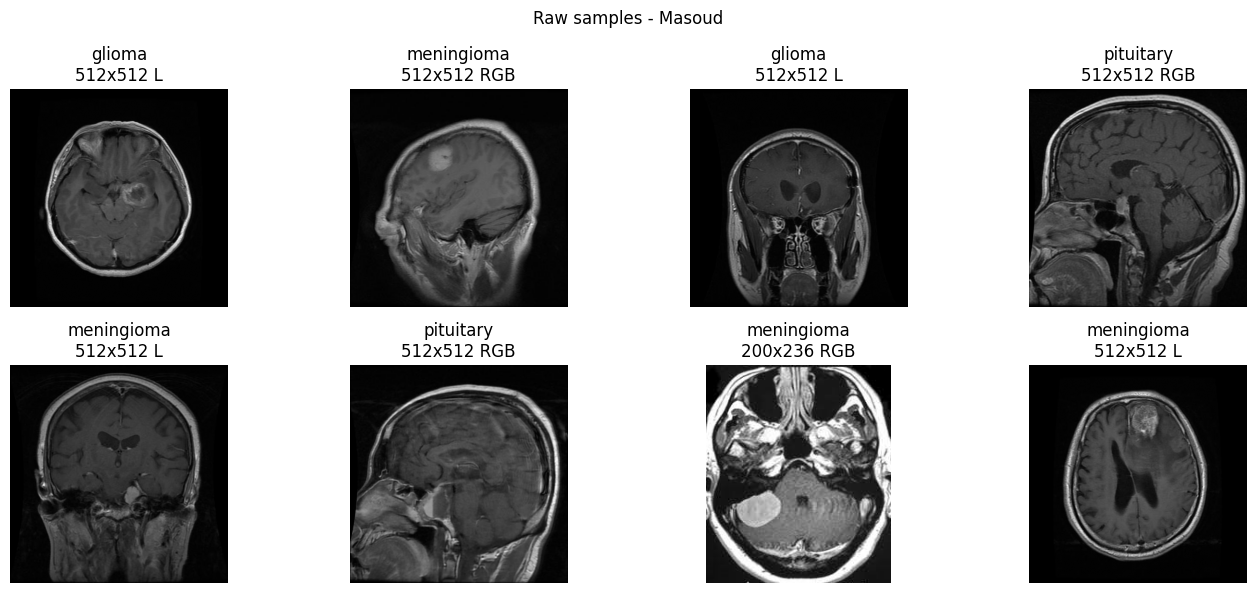

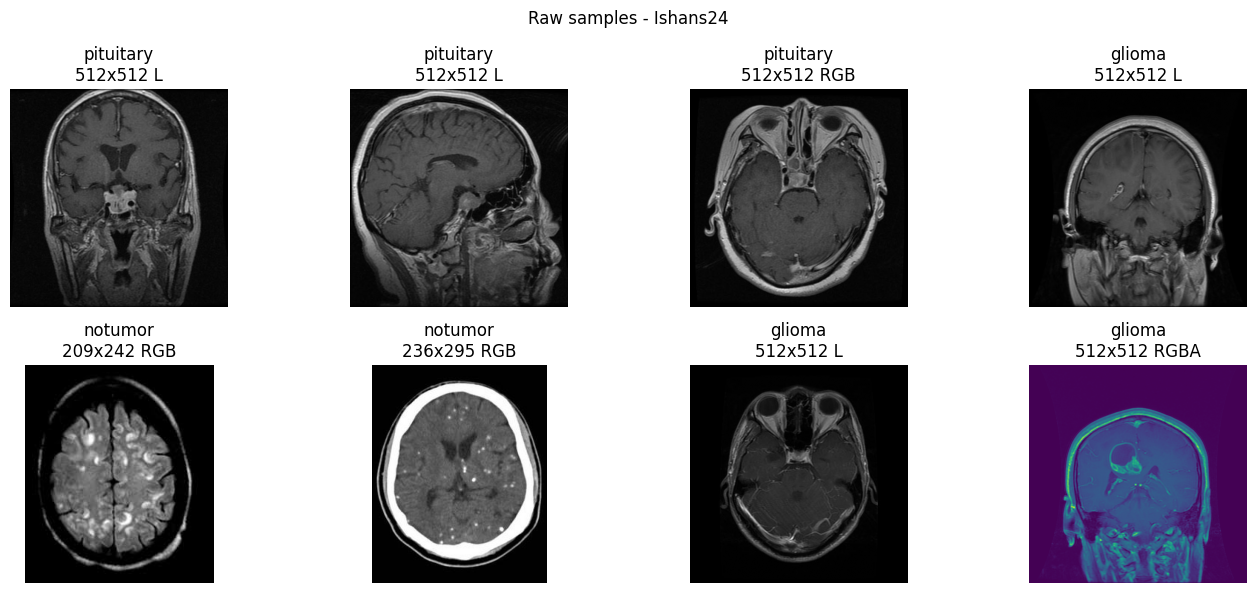

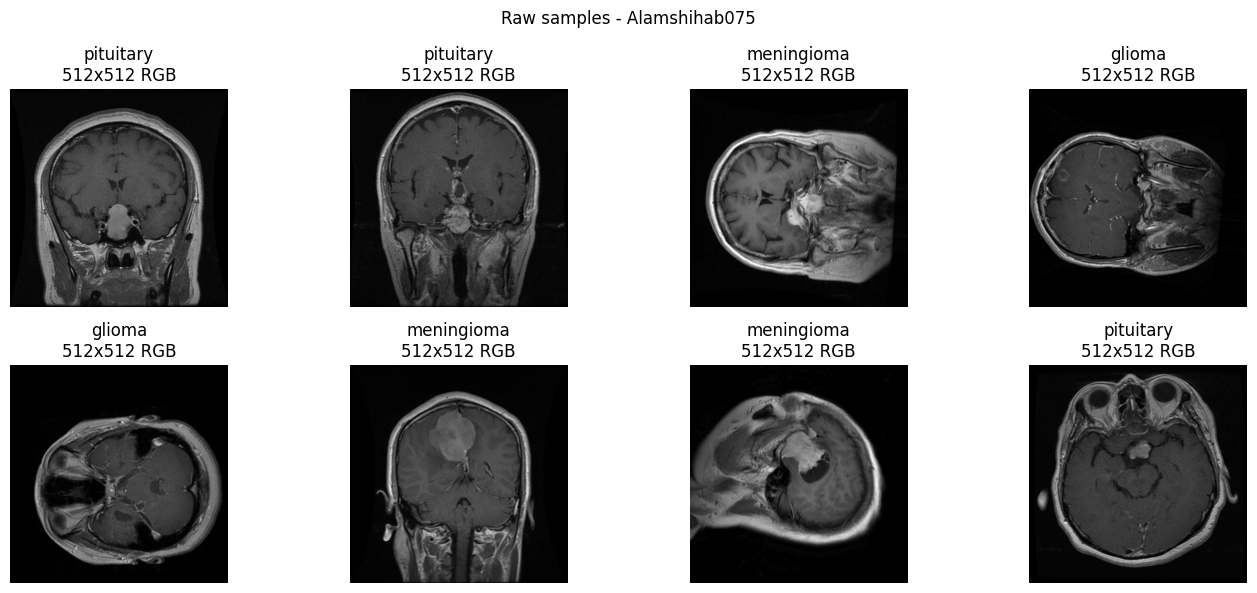

In [22]:
def show_raw_samples(dataset_name, n=8):
    temp_df = raw_df[raw_df["Dataset"] == dataset_name]
    if temp_df.empty:
        print("No images for", dataset_name)
        return

    sample_df = temp_df.sample(min(n, len(temp_df)), random_state=SEED)
    plt.figure(figsize=(14, 6))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        try:
            img = Image.open(row["Original Path"])
            plt.subplot(2, 4, i + 1)
            plt.imshow(img, cmap="gray")
            plt.title(f"{row['Class']}\n{img.size[0]}x{img.size[1]} {img.mode}")
            plt.axis("off")
        except Exception as e:
            print("Could not open:", row["Original Path"], e)

    plt.suptitle(f"Raw samples - {dataset_name}")
    plt.tight_layout()
    plt.show()


for name in dataset_paths.keys():
    show_raw_samples(name, n=8)

## 6. Preprocess every image and hash preprocessed pixels

In [23]:
def reset_directory(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)


# Reset preprocessing output to avoid mixing old and new runs.
reset_directory(PREPROCESSED_DIR)

try:
    RESAMPLE_FILTER = Image.Resampling.LANCZOS
except AttributeError:
    RESAMPLE_FILTER = Image.LANCZOS


def preprocess_image(image_path, img_size=IMG_SIZE):
    with Image.open(image_path) as img:
        img = img.convert("RGB")
        img = img.resize(img_size, RESAMPLE_FILTER)
    return img


def hash_preprocessed_image(img):
    arr = np.asarray(img)
    return hashlib.md5(arr.tobytes()).hexdigest()


processed_rows = []
failed_rows = []

total_images = len(raw_df)
for idx, row in raw_df.reset_index(drop=True).iterrows():
    dataset_name = row["Dataset"]
    class_name = row["Class"]
    original_path = row["Original Path"]

    try:
        img = preprocess_image(original_path, img_size=IMG_SIZE)
        img_hash = hash_preprocessed_image(img)

        save_dir = os.path.join(PREPROCESSED_DIR, dataset_name, class_name)
        os.makedirs(save_dir, exist_ok=True)

        save_filename = f"{dataset_name}_{idx:06d}_{img_hash}.png"
        save_path = os.path.join(save_dir, save_filename)
        img.save(save_path, format="PNG")

        processed_rows.append({
            "Dataset": dataset_name,
            "Class": class_name,
            "Original Path": original_path,
            "Original Relative Path": row["Original Relative Path"],
            "Processed Path": save_path,
            "Preprocessed Hash": img_hash,
            "Width": IMG_SIZE[0],
            "Height": IMG_SIZE[1],
            "Mode": "RGB",
        })
    except Exception as e:
        failed_rows.append({
            "Dataset": dataset_name,
            "Class": class_name,
            "Original Path": original_path,
            "Error": str(e),
        })

    if (idx + 1) % 2000 == 0 or (idx + 1) == total_images:
        print(f"Processed {idx + 1}/{total_images} images...")

processed_df = pd.DataFrame(processed_rows)
failed_df = pd.DataFrame(failed_rows)

if processed_df.empty:
    raise ValueError("All preprocessing failed; no processed images were created.")

print("Total preprocessed images:", len(processed_df))
print("Failed images:", len(failed_df))

display(processed_df.head())

processed_counts = (
    processed_df.groupby(["Dataset", "Class"])
    .size()
    .reset_index(name="Preprocessed Count")
    .sort_values(["Dataset", "Class"])
)

display(processed_counts)

processed_df.to_csv(os.path.join(REPORT_DIR, "03_preprocessed_images.csv"), index=False)
processed_counts.to_csv(os.path.join(REPORT_DIR, "04_preprocessed_class_counts.csv"), index=False)
failed_df.to_csv(os.path.join(REPORT_DIR, "05_failed_preprocessing.csv"), index=False)

Processed 2000/27017 images...
Processed 4000/27017 images...
Processed 6000/27017 images...
Processed 8000/27017 images...
Processed 10000/27017 images...
Processed 12000/27017 images...
Processed 14000/27017 images...
Processed 16000/27017 images...
Processed 18000/27017 images...
Processed 20000/27017 images...
Processed 22000/27017 images...
Processed 24000/27017 images...
Processed 26000/27017 images...
Processed 27017/27017 images...
Total preprocessed images: 27017
Failed images: 0


,Dataset,Class,Original Path,Original Relative Path,Processed Path,Preprocessed Hash,Width,Height,Mode
0,Masoud,pituitary,/home/khalid/code/simonwilliams32/MRI_project/...,Training/pituitary/Tr-pi_296.jpg,/home/khalid/code/simonwilliams32/MRI_project/...,1d2af9891ec3fd651b13e50562c36525,224,224,RGB
1,Masoud,pituitary,/home/khalid/code/simonwilliams32/MRI_project/...,Training/pituitary/Tr-pi_481.jpg,/home/khalid/code/simonwilliams32/MRI_project/...,02fcd0257f33b2489d6ba773276b9a8a,224,224,RGB
2,Masoud,pituitary,/home/khalid/code/simonwilliams32/MRI_project/...,Training/pituitary/Tr-pi_230.jpg,/home/khalid/code/simonwilliams32/MRI_project/...,f10e494ba22b0ba8be693ac385de7077,224,224,RGB
3,Masoud,pituitary,/home/khalid/code/simonwilliams32/MRI_project/...,Training/pituitary/Tr-pi_793.jpg,/home/khalid/code/simonwilliams32/MRI_project/...,79855cd7fb34502bceb443a0cd5f8162,224,224,RGB
4,Masoud,pituitary,/home/khalid/code/simonwilliams32/MRI_project/...,Training/pituitary/Tr-pi_419.jpg,/home/khalid/code/simonwilliams32/MRI_project/...,32af2c756e0c9a26d2b8c9f320b57e56,224,224,RGB


,Dataset,Class,Preprocessed Count
0,Alamshihab075,glioma,3293
1,Alamshihab075,meningioma,3593
2,Alamshihab075,notumor,811
3,Alamshihab075,pituitary,1560
4,Ishans24,glioma,3754
5,Ishans24,meningioma,2343
6,Ishans24,notumor,1757
7,Ishans24,pituitary,2706
8,Masoud,glioma,1800
9,Masoud,meningioma,1800


## 7. Find duplicates after preprocessing

In [24]:
duplicate_df = (
    processed_df.groupby("Preprocessed Hash")
    .filter(lambda x: len(x) > 1)
    .sort_values(["Preprocessed Hash", "Dataset", "Class"])
    .reset_index(drop=True)
)

if duplicate_df.empty:
    duplicate_hash_summary_df = pd.DataFrame(columns=[
        "Preprocessed Hash", "Duplicate_Entries", "Number_of_Datasets", "Classes", "Datasets"
    ])
    cross_dataset_duplicate_hashes_df = duplicate_hash_summary_df.copy()
else:
    duplicate_hash_summary_df = (
        duplicate_df.groupby("Preprocessed Hash")
        .agg(
            Duplicate_Entries=("Preprocessed Hash", "size"),
            Number_of_Datasets=("Dataset", "nunique"),
            Classes=("Class", lambda x: ", ".join(sorted(set(x)))),
            Datasets=("Dataset", lambda x: ", ".join(sorted(set(x)))),
        )
        .reset_index()
        .sort_values(["Number_of_Datasets", "Duplicate_Entries"], ascending=False)
    )

    cross_dataset_duplicate_hashes_df = duplicate_hash_summary_df[
        duplicate_hash_summary_df["Number_of_Datasets"] > 1
    ].copy()

print("Duplicate image entries after preprocessing:", len(duplicate_df))
print("Duplicate hash groups:", duplicate_df["Preprocessed Hash"].nunique() if not duplicate_df.empty else 0)
print("Duplicate hash groups appearing in more than one dataset:", len(cross_dataset_duplicate_hashes_df))

display(duplicate_df.head(100))
display(cross_dataset_duplicate_hashes_df.head(100))

duplicate_df.to_csv(os.path.join(REPORT_DIR, "06_duplicate_entries_after_preprocessing.csv"), index=False)
duplicate_hash_summary_df.to_csv(os.path.join(REPORT_DIR, "07_duplicate_hash_summary.csv"), index=False)
cross_dataset_duplicate_hashes_df.to_csv(os.path.join(REPORT_DIR, "08_cross_dataset_duplicate_hashes.csv"), index=False)

Duplicate image entries after preprocessing: 19590
Duplicate hash groups: 7175
Duplicate hash groups appearing in more than one dataset: 7175


,Dataset,Class,Original Path,Original Relative Path,Processed Path,Preprocessed Hash,Width,Height,Mode
0,Alamshihab075,pituitary,/home/khalid/code/simonwilliams32/MRI_project/...,Train/Train/Pituitary/images/p (584).jpg,/home/khalid/code/simonwilliams32/MRI_project/...,000296ed3f14282e340765e5d7b24227,224,224,RGB
1,Alamshihab075,pituitary,/home/khalid/code/simonwilliams32/MRI_project/...,test/test/Pituitary/images/Tr-pi_0532.jpg,/home/khalid/code/simonwilliams32/MRI_project/...,000296ed3f14282e340765e5d7b24227,224,224,RGB
2,Ishans24,pituitary,/home/khalid/code/simonwilliams32/MRI_project/...,pituitary/pituitary1165.jpg,/home/khalid/code/simonwilliams32/MRI_project/...,000296ed3f14282e340765e5d7b24227,224,224,RGB
3,Masoud,pituitary,/home/khalid/code/simonwilliams32/MRI_project/...,Training/pituitary/Tr-pi_24.jpg,/home/khalid/code/simonwilliams32/MRI_project/...,000296ed3f14282e340765e5d7b24227,224,224,RGB
4,Alamshihab075,meningioma,/home/khalid/code/simonwilliams32/MRI_project/...,Train/Train/Meningioma/images/Tr-me_0460.jpg,/home/khalid/code/simonwilliams32/MRI_project/...,0004a762d764396f8f5518caf1640432,224,224,RGB
...,...,...,...,...,...,...,...,...,...
95,Ishans24,meningioma,/home/khalid/code/simonwilliams32/MRI_project/...,meningioma/meningioma827.jpg,/home/khalid/code/simonwilliams32/MRI_project/...,011681873205e53c70e8c730e3fa64e4,224,224,RGB
96,Masoud,meningioma,/home/khalid/code/simonwilliams32/MRI_project/...,Training/meningioma/Tr-me_1133.jpg,/home/khalid/code/simonwilliams32/MRI_project/...,011681873205e53c70e8c730e3fa64e4,224,224,RGB
97,Alamshihab075,meningioma,/home/khalid/code/simonwilliams32/MRI_project/...,Train/Train/Meningioma/images/m2 (55).jpg,/home/khalid/code/simonwilliams32/MRI_project/...,011b482b57166bb39b8c42911eeb46e2,224,224,RGB
98,Ishans24,meningioma,/home/khalid/code/simonwilliams32/MRI_project/...,meningioma/meningioma1065.jpg,/home/khalid/code/simonwilliams32/MRI_project/...,011b482b57166bb39b8c42911eeb46e2,224,224,RGB


,Preprocessed Hash,Duplicate_Entries,Number_of_Datasets,Classes,Datasets
2082,4948cd41e195a81192b2c160952197ee,16,3,notumor,"Alamshihab075, Ishans24, Masoud"
1216,2ae817c198efa08837133cb845fd29b0,13,3,meningioma,"Alamshihab075, Ishans24, Masoud"
518,1210952b4e54f23ce1450e6c04f01211,12,3,notumor,"Alamshihab075, Ishans24, Masoud"
1473,344396fa3b3359533286e8bd1cd22bce,11,3,notumor,"Alamshihab075, Ishans24, Masoud"
2448,55caee96126e665a1b54070e234359a0,11,3,notumor,"Alamshihab075, Ishans24, Masoud"
...,...,...,...,...,...
5716,ca2fa9b233e253611aafd605053cb9b6,6,3,meningioma,"Alamshihab075, Ishans24, Masoud"
5864,cf5761e4ba32866383a43edb2a571647,6,3,meningioma,"Alamshihab075, Ishans24, Masoud"
6080,d71bf2b41416468598fb73cb26909c79,6,3,meningioma,"Alamshihab075, Ishans24, Masoud"
6188,db306467e793f4e4474e0f313370ec21,6,3,meningioma,"Alamshihab075, Ishans24, Masoud"


## 8. Deduplicate Masoud + Ishans24 for internal train/validation/test

In [25]:
internal_sources = ["Masoud", "Ishans24"]
internal_df = processed_df[processed_df["Dataset"].isin(internal_sources)].copy()

if internal_df.empty:
    raise ValueError("Internal pool is empty. Masoud and Ishans24 images were not found.")

source_priority = {"Masoud": 0, "Ishans24": 1}
internal_df["Source Priority"] = internal_df["Dataset"].map(source_priority)

internal_dedup_df = (
    internal_df.sort_values(["Preprocessed Hash", "Source Priority", "Dataset"])
    .drop_duplicates(subset=["Preprocessed Hash"], keep="first")
    .reset_index(drop=True)
)

print("Internal source images before deduplication:", len(internal_df))
print("Internal source images after deduplication:", len(internal_dedup_df))
print("Removed internal duplicates:", len(internal_df) - len(internal_dedup_df))

internal_dataset_class_counts = (
    internal_dedup_df.groupby(["Dataset", "Class"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Dataset", "Class"])
)
internal_class_counts = (
    internal_dedup_df.groupby("Class")
    .size()
    .reset_index(name="Count")
    .sort_values("Class")
)

display(internal_dataset_class_counts)
display(internal_class_counts)

internal_dedup_df.to_csv(os.path.join(REPORT_DIR, "09_internal_masoud_ishans24_deduplicated.csv"), index=False)
internal_class_counts.to_csv(os.path.join(REPORT_DIR, "10_internal_deduplicated_class_counts.csv"), index=False)

Internal source images before deduplication: 17760
Internal source images after deduplication: 10594
Removed internal duplicates: 7166


,Dataset,Class,Count
0,Ishans24,glioma,1959
1,Ishans24,meningioma,746
2,Ishans24,notumor,75
3,Ishans24,pituitary,936
4,Masoud,glioma,1779
5,Masoud,meningioma,1684
6,Masoud,notumor,1657
7,Masoud,pituitary,1758


,Class,Count
0,glioma,3738
1,meningioma,2430
2,notumor,1732
3,pituitary,2694


## 9. Deduplicate Alamshihab075 for external validation

In [26]:
alam_df = processed_df[processed_df["Dataset"] == "Alamshihab075"].copy()

if alam_df.empty:
    print("WARNING: Alamshihab075 pool is empty. External validation will be empty.")
    external_dedup_df = alam_df.copy()
else:
    internal_hashes = set(internal_dedup_df["Preprocessed Hash"])

    # Remove duplicates inside Alamshihab075 first.
    alam_unique_df = (
        alam_df.drop_duplicates(subset=["Preprocessed Hash"], keep="first")
        .reset_index(drop=True)
    )

    # Remove any Alamshihab075 image that appears in the internal pool.
    external_dedup_df = alam_unique_df[
        ~alam_unique_df["Preprocessed Hash"].isin(internal_hashes)
    ].reset_index(drop=True)

    print("Alamshihab075 original preprocessed images:", len(alam_df))
    print("Alamshihab075 unique images:", len(alam_unique_df))
    print("Final external validation images:", len(external_dedup_df))
    print("Removed Alamshihab075 images duplicated with internal pool:", len(alam_unique_df) - len(external_dedup_df))

external_class_counts = (
    external_dedup_df.groupby("Class")
    .size()
    .reset_index(name="External Validation Count")
    .sort_values("Class")
)

display(external_class_counts)

external_dedup_df.to_csv(os.path.join(REPORT_DIR, "11_external_alamshihab075_deduplicated.csv"), index=False)
external_class_counts.to_csv(os.path.join(REPORT_DIR, "12_external_deduplicated_class_counts.csv"), index=False)

Alamshihab075 original preprocessed images: 9257
Alamshihab075 unique images: 7914
Final external validation images: 4008
Removed Alamshihab075 images duplicated with internal pool: 3906


,Class,External Validation Count
0,glioma,2004
1,meningioma,2004


## 10. Stratified split: train / validation / internal test

In [27]:
if len(internal_dedup_df) == 0:
    raise ValueError("Internal deduplicated dataset is empty.")

class_counts = internal_dedup_df["Class"].value_counts()
print("Internal class counts before split:")
display(class_counts.to_frame("Count"))

if (class_counts < 3).any():
    raise ValueError("At least one class has fewer than 3 images, so stratified splitting is unsafe.")

train_val_df, internal_test_df = train_test_split(
    internal_dedup_df,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=internal_dedup_df["Class"],
)

val_adjusted_ratio = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_adjusted_ratio,
    random_state=SEED,
    stratify=train_val_df["Class"],
)

split_summary_rows = []
for split_name, df in [
    ("train", train_df),
    ("val", val_df),
    ("test", internal_test_df),
    ("external_val", external_dedup_df),
]:
    for class_name in CANONICAL_CLASSES:
        count = int((df["Class"] == class_name).sum()) if not df.empty else 0
        split_summary_rows.append({"Split": split_name, "Class": class_name, "Count": count})

split_summary_df = pd.DataFrame(split_summary_rows)

print("Split sizes:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Internal test:", len(internal_test_df))
print("External validation:", len(external_dedup_df))

display(split_summary_df)

train_df.to_csv(os.path.join(REPORT_DIR, "13_train_split.csv"), index=False)
val_df.to_csv(os.path.join(REPORT_DIR, "14_val_split.csv"), index=False)
internal_test_df.to_csv(os.path.join(REPORT_DIR, "15_internal_test_split.csv"), index=False)
split_summary_df.to_csv(os.path.join(REPORT_DIR, "16_final_split_class_counts.csv"), index=False)

Internal class counts before split:


,Count
Class,
glioma,3738
pituitary,2694
meningioma,2430
notumor,1732


Split sizes:
Train: 7415
Validation: 1589
Internal test: 1590
External validation: 4008


,Split,Class,Count
0,train,glioma,2616
1,train,meningioma,1701
2,train,notumor,1212
3,train,pituitary,1886
4,val,glioma,561
5,val,meningioma,364
6,val,notumor,260
7,val,pituitary,404
8,test,glioma,561
9,test,meningioma,365


## 11. Create final folder dataset

In [28]:
reset_directory(FINAL_DATASET_DIR)

for split_name in ["train", "val", "test", "external_val"]:
    for class_name in CANONICAL_CLASSES:
        os.makedirs(os.path.join(FINAL_DATASET_DIR, split_name, class_name), exist_ok=True)


def copy_split_images(df, split_name):
    copied_rows = []
    if df.empty:
        return copied_rows

    for i, row in df.reset_index(drop=True).iterrows():
        src = row["Processed Path"]
        class_name = row["Class"]
        img_hash = row["Preprocessed Hash"]
        dataset_name = row["Dataset"]

        dst_filename = f"{split_name}_{dataset_name}_{i:06d}_{img_hash}.png"
        dst = os.path.join(FINAL_DATASET_DIR, split_name, class_name, dst_filename)
        shutil.copy2(src, dst)

        copied_rows.append({
            "Split": split_name,
            "Class": class_name,
            "Dataset": dataset_name,
            "Source Processed Path": src,
            "Final Path": dst,
            "Preprocessed Hash": img_hash,
        })

    return copied_rows


final_copy_rows = []
final_copy_rows.extend(copy_split_images(train_df, "train"))
final_copy_rows.extend(copy_split_images(val_df, "val"))
final_copy_rows.extend(copy_split_images(internal_test_df, "test"))
final_copy_rows.extend(copy_split_images(external_dedup_df, "external_val"))

final_manifest_df = pd.DataFrame(final_copy_rows)

print("Final dataset created at:")
print(FINAL_DATASET_DIR)
display(final_manifest_df.head())

final_manifest_df.to_csv(os.path.join(REPORT_DIR, "17_final_dataset_manifest.csv"), index=False)

Final dataset created at:
/home/khalid/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset


,Split,Class,Dataset,Source Processed Path,Final Path,Preprocessed Hash
0,train,pituitary,Ishans24,/home/khalid/code/simonwilliams32/MRI_project/...,/home/khalid/code/simonwilliams32/MRI_project/...,1bb15d9a62ae98791b06f7745858a356
1,train,glioma,Masoud,/home/khalid/code/simonwilliams32/MRI_project/...,/home/khalid/code/simonwilliams32/MRI_project/...,1a18ef2b22044027a686ff45afb8caa5
2,train,meningioma,Masoud,/home/khalid/code/simonwilliams32/MRI_project/...,/home/khalid/code/simonwilliams32/MRI_project/...,414b0db119dcc6a7f3d88bd9e7683f49
3,train,pituitary,Ishans24,/home/khalid/code/simonwilliams32/MRI_project/...,/home/khalid/code/simonwilliams32/MRI_project/...,2f37397f374e82235b8467e971d2e239
4,train,pituitary,Masoud,/home/khalid/code/simonwilliams32/MRI_project/...,/home/khalid/code/simonwilliams32/MRI_project/...,ae459f0c67e6e2a3d8a3d77cb97dc6ae


## 12. Verify final dataset and check duplicate leakage

In [29]:
def collect_final_images(final_dir):
    rows = []
    for split_name in ["train", "val", "test", "external_val"]:
        for class_name in CANONICAL_CLASSES:
            class_dir = os.path.join(final_dir, split_name, class_name)
            if not os.path.exists(class_dir):
                continue

            for file in os.listdir(class_dir):
                if not file.lower().endswith(".png"):
                    continue

                path = os.path.join(class_dir, file)
                try:
                    img = preprocess_image(path, img_size=IMG_SIZE)
                    img_hash = hash_preprocessed_image(img)
                except Exception as e:
                    print("Could not hash final image:", path, e)
                    img_hash = None

                rows.append({
                    "Split": split_name,
                    "Class": class_name,
                    "Path": path,
                    "Filename": file,
                    "Hash": img_hash,
                })
    return pd.DataFrame(rows)


final_check_df = collect_final_images(FINAL_DATASET_DIR)

print("Final total images:", len(final_check_df))

final_counts_df = (
    final_check_df.groupby(["Split", "Class"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Split", "Class"])
)

display(final_counts_df)

if final_check_df.empty:
    leakage_df = pd.DataFrame(columns=final_check_df.columns)
    within_split_duplicate_df = pd.DataFrame(columns=final_check_df.columns)
else:
    leakage_df = (
        final_check_df.groupby("Hash")
        .filter(lambda x: x["Split"].nunique() > 1)
        .sort_values(["Hash", "Split"])
        .reset_index(drop=True)
    )

    within_split_duplicate_df = (
        final_check_df.groupby(["Split", "Hash"])
        .filter(lambda x: len(x) > 1)
        .sort_values(["Split", "Hash"])
        .reset_index(drop=True)
    )

print("Duplicate leakage across train/val/test/external_val:", len(leakage_df))
if len(leakage_df) > 0:
    print("WARNING: Duplicate leakage found across splits.")
    display(leakage_df.head(100))
else:
    print("Good: no duplicate images across final splits.")

print("Duplicate entries within the same split:", len(within_split_duplicate_df))
if len(within_split_duplicate_df) > 0:
    display(within_split_duplicate_df.head(100))
else:
    print("Good: no duplicate entries within individual splits.")

final_check_df.to_csv(os.path.join(REPORT_DIR, "18_final_dataset_check.csv"), index=False)
final_counts_df.to_csv(os.path.join(REPORT_DIR, "19_final_dataset_counts.csv"), index=False)
leakage_df.to_csv(os.path.join(REPORT_DIR, "20_final_split_leakage_check.csv"), index=False)
within_split_duplicate_df.to_csv(os.path.join(REPORT_DIR, "21_final_within_split_duplicate_check.csv"), index=False)

Final total images: 14602


,Split,Class,Count
0,external_val,glioma,2004
1,external_val,meningioma,2004
2,test,glioma,561
3,test,meningioma,365
4,test,notumor,260
5,test,pituitary,404
6,train,glioma,2616
7,train,meningioma,1701
8,train,notumor,1212
9,train,pituitary,1886


Duplicate leakage across train/val/test/external_val: 0
Good: no duplicate images across final splits.
Duplicate entries within the same split: 0
Good: no duplicate entries within individual splits.


## 13. Plot final class distributions

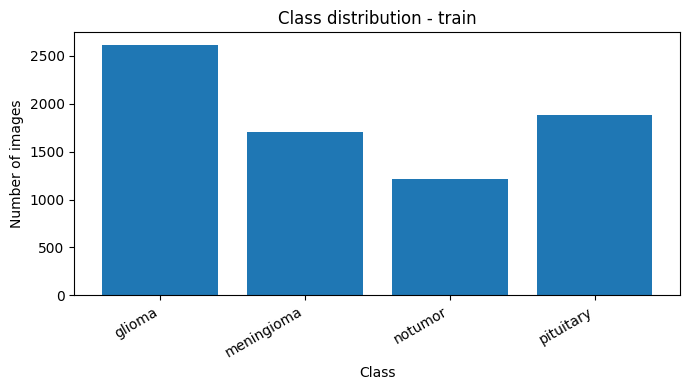

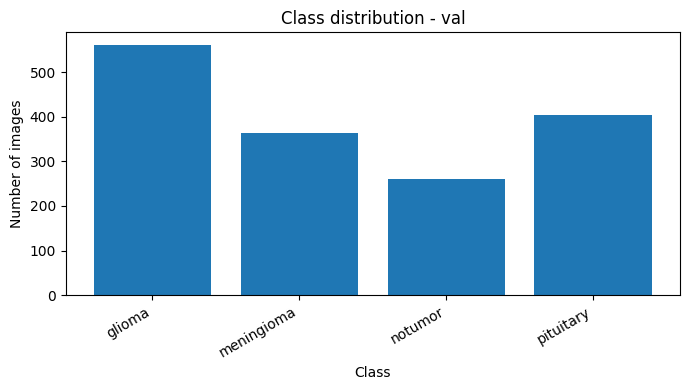

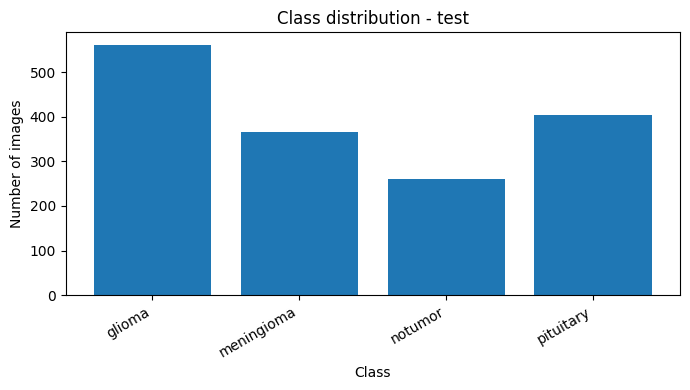

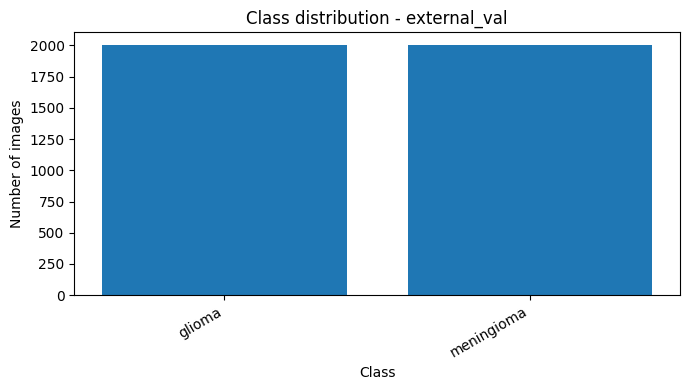

In [30]:
for split_name in ["train", "val", "test", "external_val"]:
    temp_df = final_counts_df[final_counts_df["Split"] == split_name]
    plt.figure(figsize=(7, 4))
    plt.bar(temp_df["Class"], temp_df["Count"])
    plt.title(f"Class distribution - {split_name}")
    plt.xlabel("Class")
    plt.ylabel("Number of images")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## 14. Show final sample images

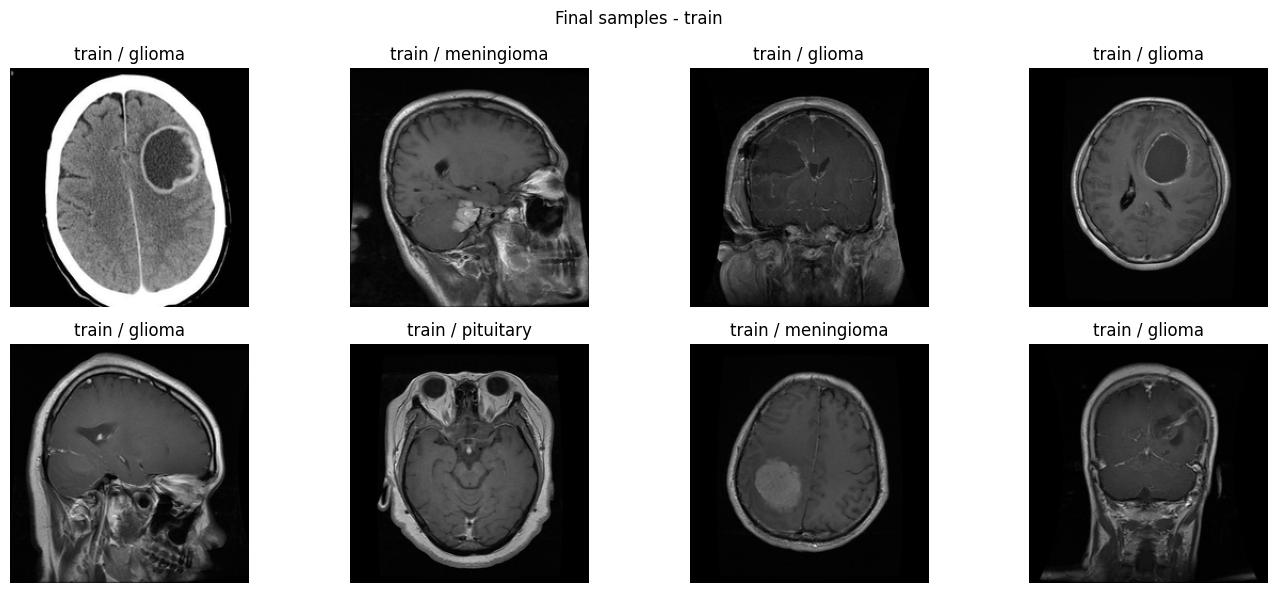

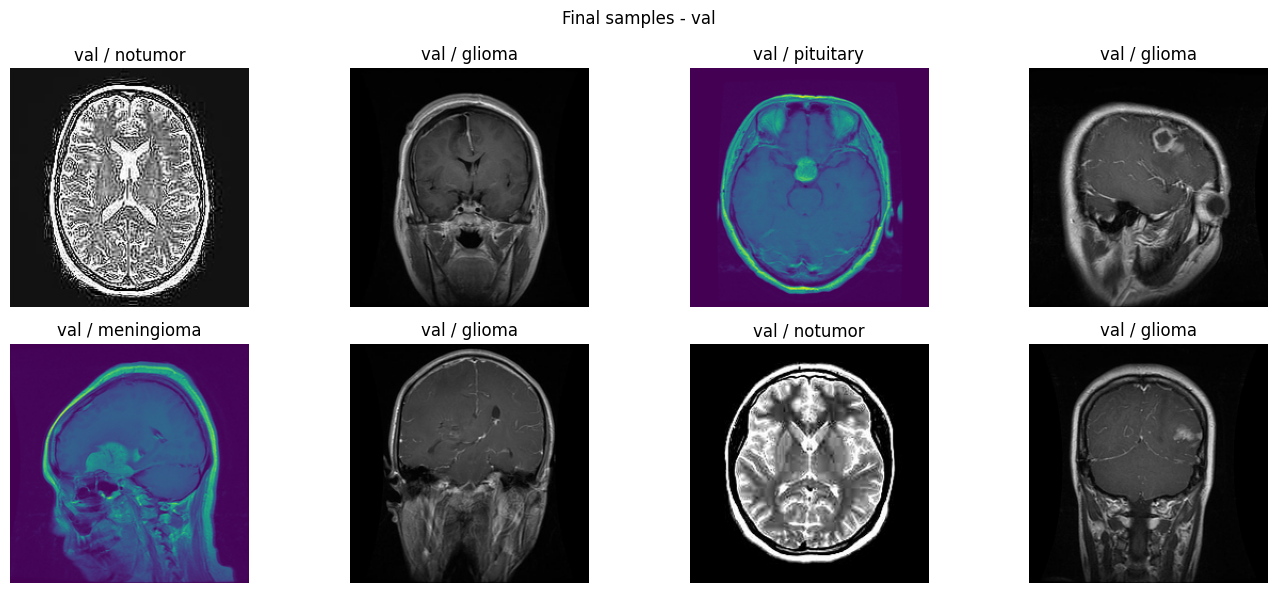

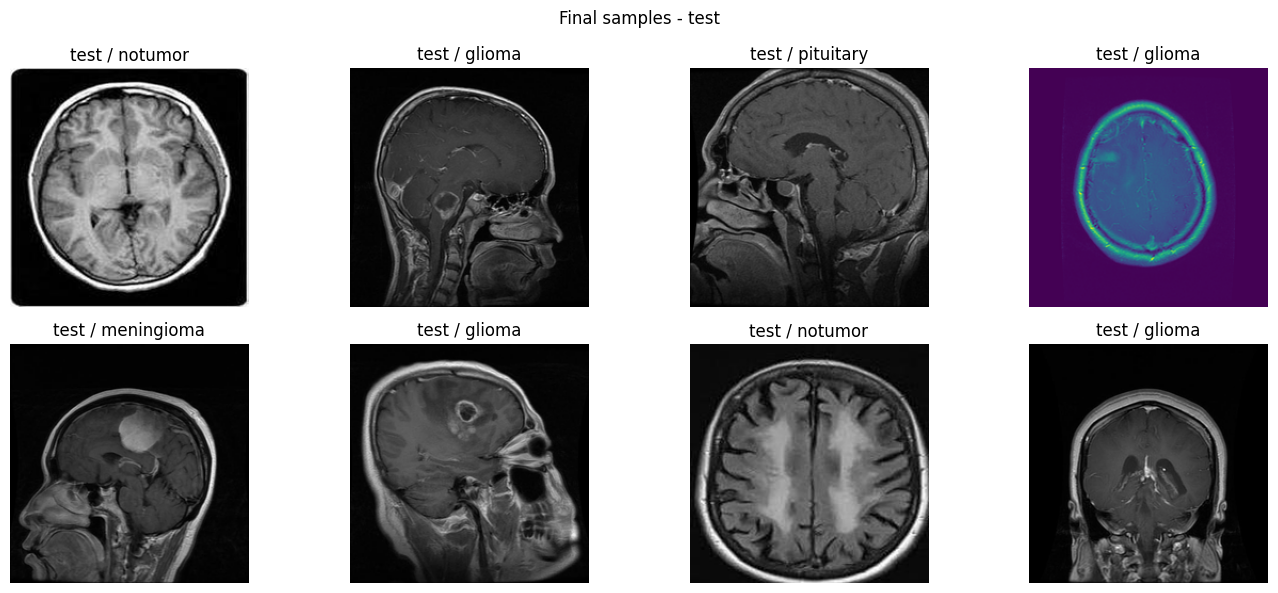

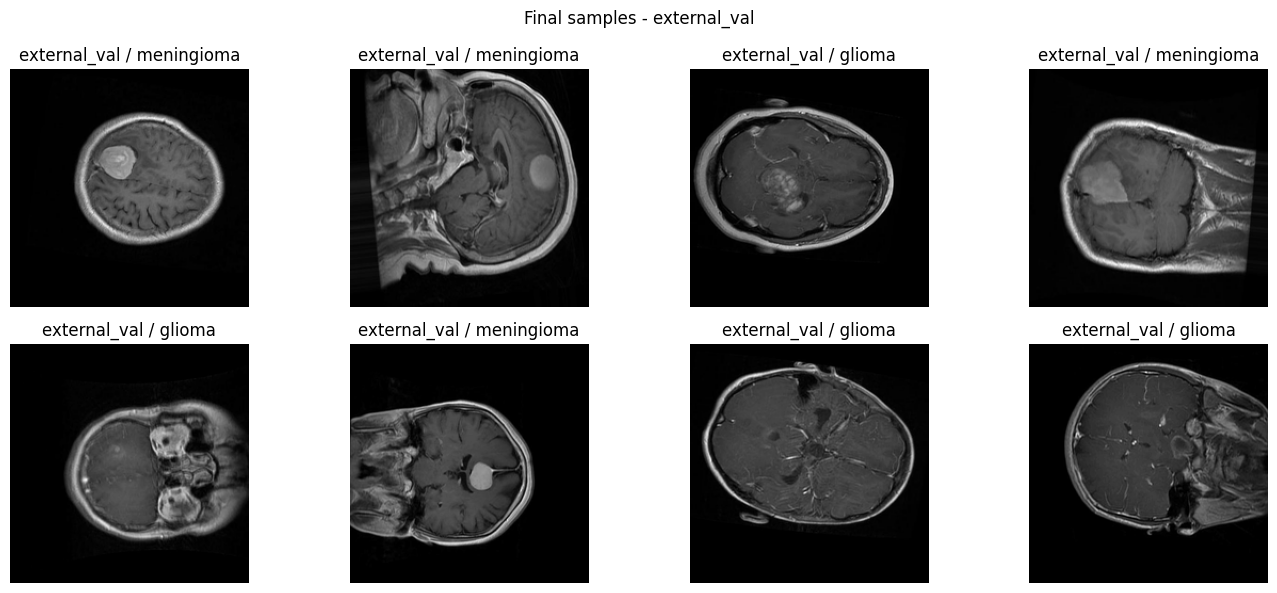

In [31]:
def show_final_samples(split_name, n=8):
    temp_df = final_check_df[final_check_df["Split"] == split_name]
    if temp_df.empty:
        print("No images for split:", split_name)
        return

    sample_df = temp_df.sample(min(n, len(temp_df)), random_state=SEED)
    plt.figure(figsize=(14, 6))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        img = Image.open(row["Path"])
        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(f"{row['Split']} / {row['Class']}")
        plt.axis("off")

    plt.suptitle(f"Final samples - {split_name}")
    plt.tight_layout()
    plt.show()


for split_name in ["train", "val", "test", "external_val"]:
    show_final_samples(split_name, n=8)

## 16. Use this output in your training notebook

In [35]:
# Copy this block into your model-training notebook after this preprocessing notebook finishes.

FINAL_DATASET_DIR = "/home/khalid/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset"

TRAIN_DIR = FINAL_DATASET_DIR + "/train"
VAL_DIR = FINAL_DATASET_DIR + "/val"
TEST_DIR = FINAL_DATASET_DIR + "/test"
EXTERNAL_VAL_DIR = FINAL_DATASET_DIR + "/external_val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
class_names = ["glioma", "meningioma", "notumor", "pituitary"]

# Uncomment to load datasets directly here.
import tensorflow as tf
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="categorical", shuffle=True, class_names=class_names
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="categorical", shuffle=False, class_names=class_names
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="categorical", shuffle=False, class_names=class_names
)
external_val_ds = tf.keras.utils.image_dataset_from_directory(
    EXTERNAL_VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="categorical", shuffle=False, class_names=class_names
)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)
external_val_ds = external_val_ds.prefetch(AUTOTUNE)

print("Training paths prepared:")
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)
print("EXTERNAL_VAL_DIR:", EXTERNAL_VAL_DIR)

I0000 00:00:1784024878.608916 1908486 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784024878.611603 1908486 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784024878.735736 1908486 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784024881.504979 1908486 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Found 7415 files belonging to 4 classes.


E0000 00:00:1784024882.123017 1908486 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1784024882.124325 1923725 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1784024882.168037 1908486 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Found 1589 files belonging to 4 classes.
Found 1590 files belonging to 4 classes.
Found 4008 files belonging to 4 classes.
Training paths prepared:
TRAIN_DIR: /home/khalid/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset/train
VAL_DIR: /home/khalid/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset/val
TEST_DIR: /home/khalid/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset/test
EXTERNAL_VAL_DIR: /home/khalid/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset/external_val


## Paper methodology text

You can use this in the preprocessing section:

> All images from the Masoud, Ishans24, and Alamshihab075 brain tumor MRI datasets were standardized to RGB format and resized to 224 × 224 pixels. MD5 hashes were computed from the standardized pixel arrays rather than from the original files, allowing duplicate detection after preprocessing. The Masoud and Ishans24 datasets were combined and deduplicated, then split using stratified sampling into training, validation, and internal testing subsets. The Alamshihab075 dataset was reserved only for external validation. Any Alamshihab075 image whose preprocessed hash matched the internal dataset was removed to reduce duplicate leakage.

## Converting blueish images to gray

In [38]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import tensorflow as tf

MAIN_DIR = "/home/khalid/code/simonwilliams32/MRI_project"



FINAL_DATASET_DIR = os.path.join(MAIN_DIR, "raw_data", "final_brain_tumor_preprocessed_dataset")

TRAIN_DIR = FINAL_DATASET_DIR + "/train"
VAL_DIR = FINAL_DATASET_DIR + "/val"
TEST_DIR = FINAL_DATASET_DIR + "/test"
EXTERNAL_VAL_DIR = FINAL_DATASET_DIR + "/external_val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

class_names = ["glioma", "meningioma", "notumor", "pituitary"]
IMAGE_EXTS = (".png", ".jpg", ".jpeg")

##### Convert blueish images into gray

def is_grayscale(path):
    """Returns True if image is black & white (all RGB channels equal)."""
    try:
        img = Image.open(path).convert("RGB")
        arr = np.array(img)
        return np.array_equal(arr[:, :, 0], arr[:, :, 1]) and np.array_equal(arr[:, :, 1], arr[:, :, 2])
    except Exception as e:
        print(f"Error reading {path}: {e}")
        return None

results = []

for split in os.listdir(FINAL_DATASET_DIR):
    split_path = os.path.join(FINAL_DATASET_DIR, split)
    if not os.path.isdir(split_path):
        continue

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if not os.path.isdir(class_path):
            continue

        for fname in os.listdir(class_path):
            if not fname.lower().endswith(IMAGE_EXTS):
                continue
            fpath = os.path.join(class_path, fname)
            gray = is_grayscale(fpath)
            results.append({
                "split": split,
                "class": class_name,
                "filename": fname,
                "path": fpath,
                "is_grayscale": gray
            })

df = pd.DataFrame(results)

print(f"Total images checked: {len(df)}")
print(f"Grayscale: {(df['is_grayscale'] == True).sum()}")
print(f"Colormapped/Color: {(df['is_grayscale'] == False).sum()}")
print(f"Errors/unreadable: {df['is_grayscale'].isna().sum()}")

print("\nBreakdown by split and class:")
summary = df.groupby(["split", "class"])["is_grayscale"].value_counts().unstack(fill_value=0)
print(summary)

def convert_to_grayscale_and_save(path):
    """Convert an image to grayscale (L), then save it back as 3-channel RGB
    so shape/format stays consistent with the rest of the pipeline."""
    try:
        img = Image.open(path).convert("RGB")
        gray = img.convert("L")
        gray_rgb = Image.merge("RGB", (gray, gray, gray))
        gray_rgb.save(path)
        return True
    except Exception as e:
        print(f"Error converting {path}: {e}")
        return False

# Only touch the ones flagged as colorized
to_fix = df[df["is_grayscale"] == False]
print(f"\nConverting {len(to_fix)} colorized images to grayscale...")

converted = 0
failed = 0
for path in to_fix["path"]:
    if convert_to_grayscale_and_save(path):
        converted += 1
    else:
        failed += 1

print(f"Converted: {converted}")
print(f"Failed: {failed}")


# load datasets

train_ds = tf.keras.utils.image_dataset_from_directory(
     TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
     label_mode="categorical", shuffle=True, class_names=class_names
 )
val_ds = tf.keras.utils.image_dataset_from_directory(
     VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
     label_mode="categorical", shuffle=False, class_names=class_names
 )
test_ds = tf.keras.utils.image_dataset_from_directory(
     TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
     label_mode="categorical", shuffle=False, class_names=class_names
)
external_val_ds = tf.keras.utils.image_dataset_from_directory(
     EXTERNAL_VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
     label_mode="categorical", shuffle=False, class_names=class_names
 )


print("Training paths prepared:")
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)
print("EXTERNAL_VAL_DIR:", EXTERNAL_VAL_DIR)

Total images checked: 14602
Grayscale: 14602
Colormapped/Color: 0
Errors/unreadable: 0

Breakdown by split and class:
is_grayscale             True
split        class           
external_val glioma      2004
             meningioma  2004
test         glioma       561
             meningioma   365
             notumor      260
             pituitary    404
train        glioma      2616
             meningioma  1701
             notumor     1212
             pituitary   1886
val          glioma       561
             meningioma   364
             notumor      260
             pituitary    404

Converting 0 colorized images to grayscale...
Converted: 0
Failed: 0
Found 7415 files belonging to 4 classes.
Found 1589 files belonging to 4 classes.
Found 1590 files belonging to 4 classes.
Found 4008 files belonging to 4 classes.
Training paths prepared:
TRAIN_DIR: /home/khalid/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset/train
VAL_DIR: /home/khalid/code/simon

## Scaling

In [39]:
#SCALING!
#Inspect Shape
images, labels = next(iter(train_ds))
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Image dtype:", images.dtype)
print("\nFirst image shape:", images[0].shape)
print("First label:", labels[0])

#Next block
#check pixel values
for images, labels in train_ds.take(5):
    print(images.numpy().min(),
          images.numpy().max())

#Next block
#Scale down pixel values
train_ds_scaled = train_ds.map(lambda images, labels: (images / 255.0, labels))
val_ds_scaled = val_ds.map(lambda images, labels: (images / 255.0, labels))
test_ds_scaled = test_ds.map(lambda images, labels: (images / 255.0, labels))
external_val_ds_scaled = external_val_ds.map(lambda images, labels: (images / 255.0, labels))

#Next block
#Check that scaling has been done (shouls be between 0 and 1)
images, labels = next(iter(train_ds_scaled))
print(images.numpy().min())
print(images.numpy().max())
print(images.dtype)

Images shape: (32, 224, 224, 3)
Labels shape: (32, 4)
Image dtype: <dtype: 'float32'>

First image shape: (224, 224, 3)
First label: tf.Tensor([1. 0. 0. 0.], shape=(4,), dtype=float32)
0.0 255.0
0.0 255.0
0.0 255.0
0.0 255.0
0.0 255.0
0.0
1.0
<dtype: 'float32'>


## Returning every image from RGB to grayscale

In [40]:
#convert every image to one-channel grayscale (instead of RGB because we already have gray images)
# this decreases the data size 3X, makes the analysis faster

train_ds_scaled = train_ds_scaled.map(lambda x, y: (tf.image.rgb_to_grayscale(x), y))
val_ds_scaled = val_ds_scaled.map(lambda x, y: (tf.image.rgb_to_grayscale(x), y))
test_ds_scaled = test_ds_scaled.map(lambda x, y: (tf.image.rgb_to_grayscale(x), y))
external_val_ds_scaled = external_val_ds_scaled.map(lambda x, y: (tf.image.rgb_to_grayscale(x), y))

In [41]:
images, labels = next(iter(train_ds_scaled))
print("Shape after grayscale conversion:", images.shape)  # expect (32, 224, 224, 1)

Shape after grayscale conversion: (32, 224, 224, 1)


## Autotuning

In [ ]:
# this was part of the already available preprocessing pipeline
# it increasing efficieny

# AUTOTUNE = tf.data.AUTOTUNE

# train_ds_scaled = train_ds_scaled.prefetch(AUTOTUNE)
# val_ds_scaled = val_ds_scaled.prefetch(AUTOTUNE)
# test_ds_scaled = test_ds_scaled.prefetch(AUTOTUNE)
# external_val_ds_scaled = external_val_ds_scaled.prefetch(AUTOTUNE)

In [55]:
df

,split,class,filename,path,is_grayscale
0,external_val,meningioma,external_val_Alamshihab075_002977_4469a4b44cec...,/home/khalid/code/simonwilliams32/MRI_project/...,True
1,external_val,meningioma,external_val_Alamshihab075_002063_f8bc6ba59c0a...,/home/khalid/code/simonwilliams32/MRI_project/...,True
2,external_val,meningioma,external_val_Alamshihab075_003268_b313ea5f0d79...,/home/khalid/code/simonwilliams32/MRI_project/...,True
3,external_val,meningioma,external_val_Alamshihab075_003733_34c7cadb6ffc...,/home/khalid/code/simonwilliams32/MRI_project/...,True
4,external_val,meningioma,external_val_Alamshihab075_003791_0827b185247a...,/home/khalid/code/simonwilliams32/MRI_project/...,True
...,...,...,...,...,...
14597,val,notumor,val_Masoud_000243_64fd3b2b0a7b6fc14dbcf1a43e85...,/home/khalid/code/simonwilliams32/MRI_project/...,True
14598,val,notumor,val_Masoud_000771_a2e8495c26e9e7f77ee0274a9fad...,/home/khalid/code/simonwilliams32/MRI_project/...,True
14599,val,notumor,val_Masoud_001073_b1935714aca3bb1c6048ebc02e25...,/home/khalid/code/simonwilliams32/MRI_project/...,True
14600,val,notumor,val_Masoud_001412_7f808747dc84f4c87dc4985d91b4...,/home/khalid/code/simonwilliams32/MRI_project/...,True


In [69]:
from tensorflow.keras import Sequential, Input, layers

#### 1. ARCHITECTURE

model = Sequential()

# model.add(Input(shape=(224, 224, 1)))

# model.add(layers.Conv2D(6, kernel_size=(3, 3), activation='relu'))
# model.add(layers.Conv2D(4, kernel_size=(3), activation='relu')) # kernel_size = 3 <==> (3, 3)
# model.add(layers.Flatten())

model.add(Input(shape=(224, 224, 1))),
model.add(layers.Reshape((224, 224, 1))),
model.add(layers.Conv2D(16, (3, 3), padding='same', activation="relu")),
model.add(layers.MaxPool2D(pool_size=(2, 2))),
model.add(layers.Conv2D(32, (2, 2), padding='same', activation="relu")),
model.add(layers.MaxPool2D(pool_size=(2, 2))),
model.add(layers.Flatten()),
model.add(layers.Dense(50, activation='relu')),
model.add(layers.Dropout(0.3)),
model.add(layers.Dense(4, activation='softmax'))
model.summary()

# tf.keras.applications.VGG16(
#     include_top=True,
#     weights='imagenet',
#     input_tensor=None,
#     input_shape=None,
#     pooling=None,
#     classes=1000,
#     classifier_activation='softmax'
# )

# tf.keras.applications.ResNet50(
#     include_top=True,
#     weights='imagenet',
#     input_tensor=None,
#     input_shape=None,
#     pooling=None,
#     classes=1000,
#     classifier_activation='softmax'
# )


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_5 (Reshape)             │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 32)   │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 50)             │     5,017,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,020,094 (19.15 MB)

 Trainable params: 5,020,094 (19.15 MB)

 Non-trainable params: 0 (0.00 B)

In [70]:
from tensorflow.keras import optimizers
adam_opt = optimizers.Adam(learning_rate=0.01, beta_1=0.9, beta_2=0.999)

# Classification with more classes
model.compile(loss='categorical_crossentropy',
              optimizer=adam_opt,
              metrics=['accuracy'])

In [73]:

from tensorflow.keras import callbacks

es = callbacks.EarlyStopping(patience=5, restore_best_weights=True)

model.fit(train_ds_scaled,
          batch_size=16, # Batch size -too small--> no generalization
          epochs=100,
          validation_data=val_ds_scaled, #            -too large--> slow computations
          callbacks=[es],
          verbose=1)

Epoch 1/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8665 - loss: 0.3294

W0000 00:00:1784043844.735030 1983042 png_io.cc:96] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


232/232 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - accuracy: 0.8759 - loss: 0.3126 - val_accuracy: 0.8571 - val_loss: 0.4860
Epoch 2/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8898 - loss: 0.2744

W0000 00:00:1784043863.051463 1983202 png_io.cc:96] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


232/232 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - accuracy: 0.8905 - loss: 0.2798 - val_accuracy: 0.8597 - val_loss: 0.4411
Epoch 3/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9039 - loss: 0.2599

...

232/232 ━━━━━━━━━━━━━━━━━━━━ 20s 74ms/step - accuracy: 0.9377 - loss: 0.1618 - val_accuracy: 0.8804 - val_loss: 0.5333
Epoch 7/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9434 - loss: 0.1475

W0000 00:00:1784043958.318057 1983948 png_io.cc:96] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


232/232 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.9392 - loss: 0.1674 - val_accuracy: 0.8364 - val_loss: 0.5573
Epoch 8/100
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9336 - loss: 0.1614

W0000 00:00:1784043976.214279 1984113 png_io.cc:96] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


232/232 ━━━━━━━━━━━━━━━━━━━━ 19s 83ms/step - accuracy: 0.9424 - loss: 0.1451 - val_accuracy: 0.8867 - val_loss: 0.5142


In [72]:
model.evaluate(test_ds_scaled)

11/50 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9270 - loss: 0.2372

W0000 00:00:1784043207.548159 1981186 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8673 - loss: 0.3674


[0.3674120306968689, 0.8672956228256226]